# Predikcija inflacije u Srbiji

Cilj ovog projekta je analiza i predikcija mesečne inflacije u Srbiji korišćenjem vremenskih serija.

Razumevanje inflacije:

Inflacija je opšti, postepeni porast cena robe i usluga, ili pad vrednosti novca. Ona predstavlja jednu od osnovnih mera kojima se opisuje ekonomija određene zemlje. Najjednostavniji način za suzbijanje (obuzdavanje) inflacije je podizanje kamatnih stopa. Kada su kamatne stope niske, pojedinci i preduzeća imaju tendenciju da traže više kredita.

Koristi se SARIMAX model, uz prethodnu analizu stacionarnosti, sezonalnosti i autokorelacije podataka.


In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller


full_data_raw = pd.read_csv('data/Train.csv', sep=';')

temp_data = full_data_raw[full_data_raw['skrIndikator'].str.contains('Lančani', na=False)].copy()

meseci_map = {
    'januar': '01', 'februar': '02', 'mart': '03', 'april': '04', 
    'maj': '05', 'jun': '06', 'jul': '07', 'avgust': '08', 
    'septembar': '09', 'oktobar': '10', 'novembar': '11', 'decembar': '12'
}

def konvertuj(tekst):
    try:
        godina, mesec = str(tekst).split('/')
        return f"{godina}-{meseci_map[mesec]}-01"
    except:
        return None

temp_data['nVrTacka'] = temp_data['nVrTacka'].apply(konvertuj)
temp_data['nVrTacka'] = pd.to_datetime(temp_data['nVrTacka'])

temp_data = temp_data[['nVrTacka', 'Vrednost']].dropna().sort_values('nVrTacka').set_index('nVrTacka')
temp_data['Inflacija'] = temp_data['Vrednost'] - 100
temp_data = temp_data.asfreq('MS')


split_point = int(len(temp_data) * 0.8)

df = temp_data.iloc[:split_point]      
test_df = temp_data.iloc[split_point:] 

## Vizualizacija podataka

Na grafiku je prikazana mesečna inflacija. Može se uočiti promenljiv trend i potencijalna sezonalnost.

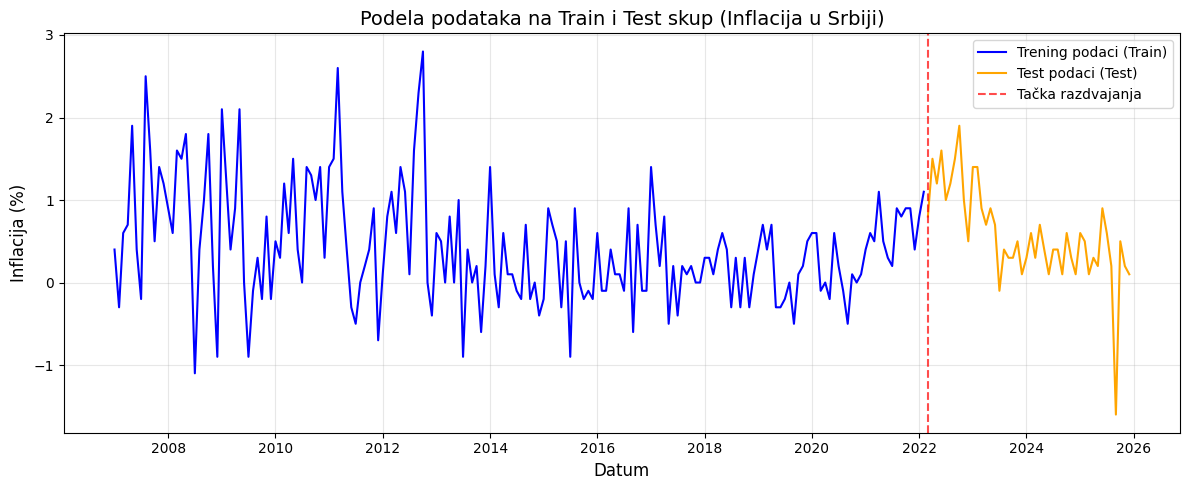

In [156]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Inflacija'], label='Trening podaci (Train)', color='blue', linewidth=1.5)
plt.plot(test_df.index, test_df['Inflacija'], label='Test podaci (Test)', color='orange', linewidth=1.5)
plt.axvline(x=test_df.index[0], color='red', linestyle='--', alpha=0.7, label='Tačka razdvajanja')

plt.title('Podela podataka na Train i Test skup (Inflacija u Srbiji)', fontsize=14)
plt.xlabel('Datum', fontsize=12)
plt.ylabel('Inflacija (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Test stacionarnosti (ADF test)

Za testiranje stacionarnosti koristimo ADF test (*Augmented Dickey–Fuller*). Sa 95% tačnosti (p-vrednost ≤ 0.05) tvrdimo da je vremenska serija stacionarna kada je ADF ≤ -2.862. Umesto ADF vrednosti možemo koristiti p-vrednost. Ako je konkretna `p-vrednost ≤ 0.05` => 95% smo sigurni da je vremenska serija stacionarna.

Ako je p-vrednost manja od 0.05, serija je stacionarna. U suprotnom, potrebno je diferenciranje.

U našem slučaju p vrednost je malo veca od 0.05 zbog toga se odlucujemo na diferenciranje iako je blizu stacionarnosti.


In [157]:
adf_result = adfuller(df['Inflacija'].dropna())
adf_value = adf_result[0]
p_value = adf_result[1]

print(f'{adf_value=:.2f}, {p_value=:.2f}')

if p_value <= 0.05:
    print('postoji stacionarnost')
else:
    print('ne postoji stacionarnost')

adf_value=-2.79, p_value=0.06
ne postoji stacionarnost


## Dekompozicija serije

STL dekompozicija razdvaja seriju na:
- trend
- sezonalnost
- rezidual
- šum

Ovo pomaže da bolje razumemo strukturu podataka.

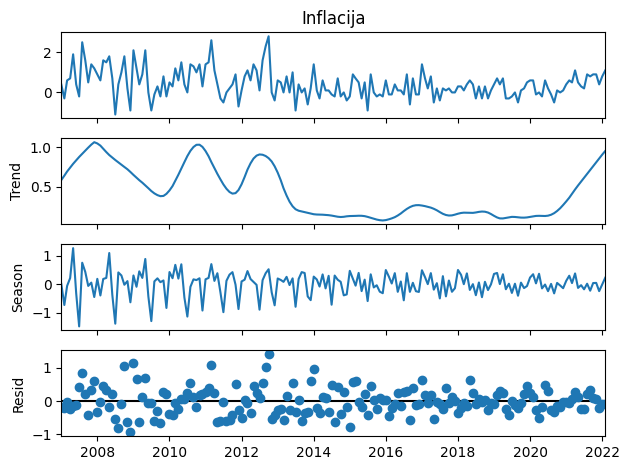

In [158]:
from statsmodels.tsa.seasonal import STL
stl = STL(df['Inflacija']).fit()
stl.plot()
plt.show()

## Diferenciranje

Pošto serija nije bila stacionarna, primenjeno je diferenciranje.

Nakon toga ponovo se radi ADF test kako bi se proverila stacionarnost.

ADF statistika: -7.1814
p-value: 0.0000
Serija je sada stacionarna.


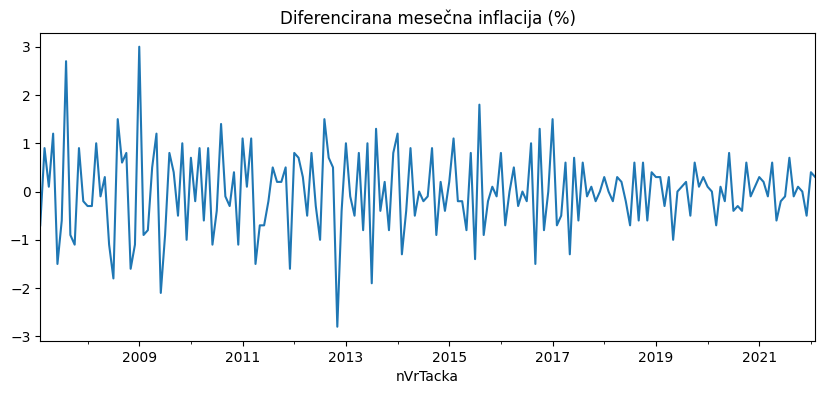

In [159]:
stationary_data = df['Inflacija'].diff().dropna()

result = adfuller(stationary_data)

print(f"ADF statistika: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

if result[1] <= 0.05:
    print("Serija je sada stacionarna.")
else:
    print("Serija i dalje nije stacionarna.")

stationary_data.plot(figsize=(10,4), title='Diferencirana mesečna inflacija (%)')
plt.show()

### Ljung–Box Q test
Koristimo ga da bismo utvrdili da li postoji autokorelacija u podacima.
Hipoteze testa su:

- H₀ (nulta hipoteza): Nema autokorelacije do određenog reda h.
- H₁ (alternativna): Postoji autokorelacija barem na nekom od prvih h lagova.

Do zaključaka da li autokorelacija reda h postoji ili ne dolazimo posmatrajući p vrednost:
- Ako je p-vrednost > 0.05, ne odbacujemo H₀ → nema značajne autokorelacije.
- Ako je p-vrednost < 0.05, odbacujemo H₀ → postoji autokorelacija.

In [160]:
result = acorr_ljungbox(stationary_data, lags=15, return_df=True)
result

,lb_stat,lb_pvalue
1,26.379629,2.804831e-07
2,30.036424,3.003817e-07
3,30.426471,1.122458e-06
4,32.897369,1.253689e-06
5,32.935392,3.876251e-06
6,33.540056,8.252560e-06
7,34.080930,1.663423e-05
8,34.920118,2.764930e-05
9,39.032750,1.136497e-05
10,39.311430,2.239009e-05


Kolona <b>lb_pvalue</b> prikazuje p vrednost za svaki od 15 lag-ova (prethodnih 1, 2..., 15 meseci). Sve vrednosti su <b>ispod 0.05</b>, pa zaključujemo da <b>postoji autokorelacija</b> za svaki od lag-ova, odnosno, treba dodatno proveriti sve opsege vrednosti na <b>autokorelogramu</b>, kako bi se zaključilo koji raspon meseci nam može značiti prilikom proširivanja skupa podataka novim kolonama.

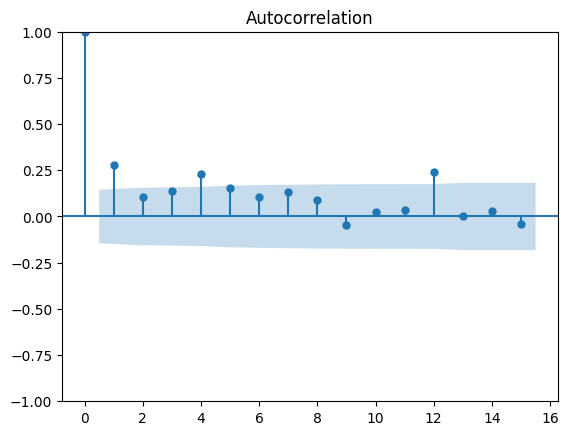

In [161]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Inflacija'], lags=15)
plt.show()

**Tumačenje:** lagovi koji prelaze granice poverenja ukazuju na statistički značajnu autokorelaciju a to su lagovi (1, 4, 12), ostali lagovi nemaju značaj za naš model ili su šum. Pošto smo se odlučili na Sarima model koji uzima u obzir sezonalnost lag12 necemo koristiti, isprobaćemo roling window sa širinom prozora 4.

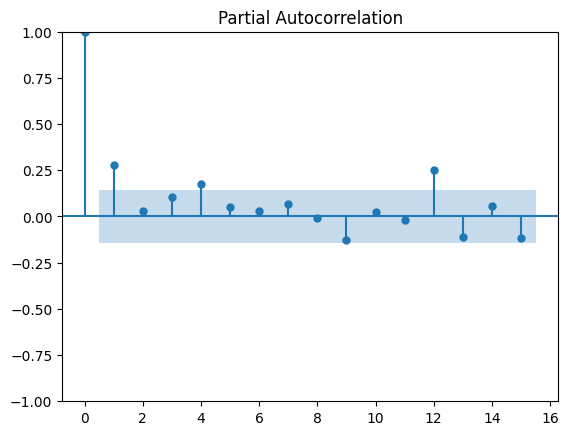

In [162]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['Inflacija'], lags=15)
plt.show()

**Tumačenje:** Sa sledećeg grafika vidimo da samo nekoliko vrednosti za $k$ ima PACF vrednost. Za k=4, primećujemo značajnu vrednost, ali gotovo na granici. Dok vrednosti k=1 i k=12 imaju značajniju vrednost, što znači da postoji jak direktan uticaj prošlog i 12. prošlog meseca u odnosu na sadašnji.

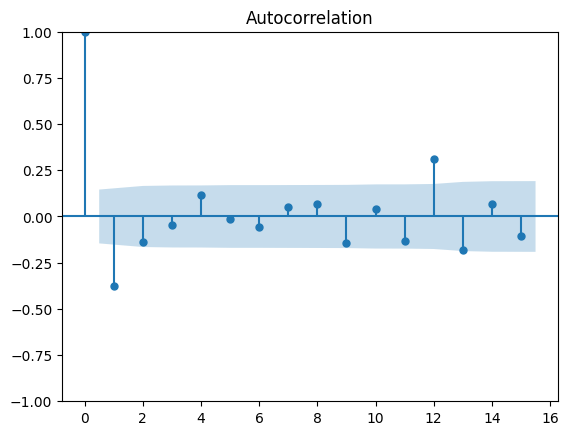

In [163]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(stationary_data, lags=15)
plt.show()

Parametar q (red MA komponente) određen je analizom ACF funkcije. Uočeni su statistički značajni koeficijenti autokorelacije na prvim lagovima

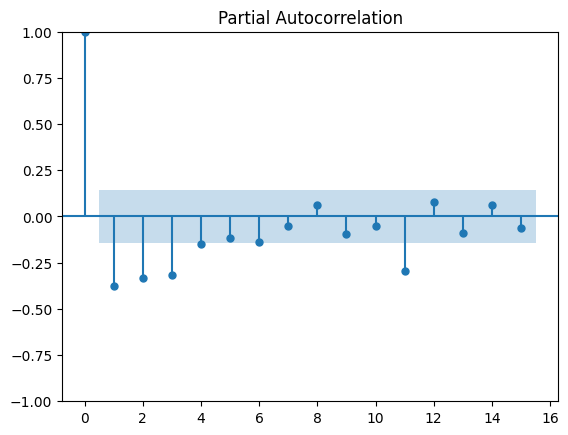

In [164]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(stationary_data, lags=15, method='ols')
plt.show()

Za p-vrednost mozemo uzeti (1,2,3,11), odlucili smo se na p=3.



### Dodavanje novi kolona.

Kako bismo poboljšali prediktivnu moć modela, uvodimo eksterne regresore zasnovane na istorijskim podacima. Na osnovu prethodne analize autokorelacije (ACF i PACF), identifikovali smo snažnu zavisnost trenutne inflacije od njenih prethodnih vrednosti.

Lag 1 (Kašnjenje od jednog meseca): Uvodimo vrednost inflacije iz prethodnog meseca kao direktan indikator inercije cena. Visoka korelacija na prvom lagu sugeriše da je prošlomesečna inflacija najbolji pojedinačni prediktor tekuće inflacije.

Rolling Mean 4 (Pokretni prosek kvartala): Koristimo prosek inflacije u poslednja četiri meseca kako bismo "ispeglali" kratkoročne šumove i modelu pružili informaciju o lokalnom trendu. Prozor od 4 meseca je izabran kako bi obuhvatio kvartalne promene i stabilizovao predviđanje.

Nakon generisanja ovih varijabli, vršimo proveru njihove korelacije sa ciljnom promenljivom (Inflacija) kako bismo potvrdili njihovu relevantnost pre same obuke modela.

In [165]:
temp_data['Lag1'] = temp_data['Inflacija'].shift(1)
temp_data['Rolling_Mean_4'] = temp_data['Inflacija'].shift(1).rolling(window=4).mean()

temp_data = temp_data.dropna()

split_idx = int(len(temp_data) * 0.8)
df_train = temp_data.iloc[:split_idx]
df_test = temp_data.iloc[split_idx:]


# 4. Provera korelacije novih varijabli
print("Korelacija varijabli sa Inflacijom:")
print(temp_data[['Inflacija','Lag1','Rolling_Mean_4']].corr()['Inflacija'])

Korelacija varijabli sa Inflacijom:
Inflacija         1.000000
Lag1              0.322169
Rolling_Mean_4    0.361977
Name: Inflacija, dtype: float64


## SARIMAX model

Na osnovu prethodne analize, primenjen je SARIMAX model za predikciju inflacije.

Model uzima u obzir i sezonalnost i trend u podacima.

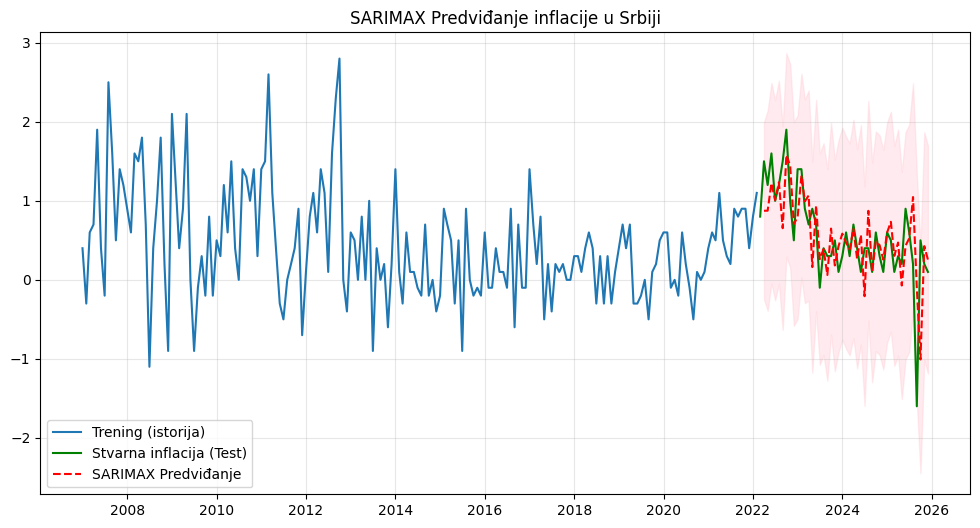

In [169]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
exog_vars = ['Lag1','Rolling_Mean_4']

y_train = df_train['Inflacija']
X_train = df_train[exog_vars]

y_test = df_test['Inflacija']
X_test = df_test[exog_vars]
# 1. Definisanje SARIMAX modela
# Redosled (p, d, q) je za trend, a (P, D, Q, s) je za sezonalnost (12 meseci)
# Ove parametre (1,0,1) uzimamo kao polaznu tačku za inflaciju
model = sm.tsa.statespace.SARIMAX(y_train,
                                exog=X_train,
                                order=(3, 1, 1),              # (p, d, q)
                                seasonal_order=(0, 1, 1, 12),   # (P, D, Q, s)
                                enforce_stationarity=False,
                                enforce_invertibility=False)

results = model.fit()

forecast = results.get_forecast(steps=len(y_test),exog=X_test)
forecast_df = forecast.summary_frame()

plt.figure(figsize=(12, 6))
plt.plot(df['Inflacija'], label='Trening (istorija)')
plt.plot(test_df['Inflacija'], label='Stvarna inflacija (Test)', color='green')
plt.plot(forecast_df['mean'], label='SARIMAX Predviđanje', color='red', linestyle='--')

plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], color='pink', alpha=0.3)

plt.title('SARIMAX Predviđanje inflacije u Srbiji')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Evaluacija modela

Model je evaluiran pomoću:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

Manje vrednosti znače bolju preciznost modela.

Model postiže MAE od 0.34% i RMSE od 0.47%, što ukazuje na relativno visoku preciznost predikcije.

Razlika između MAE i RMSE nije velika, što znači da model nema veliki broj ekstremnih grešaka.

In [170]:
mae = mean_absolute_error(y_test, forecast_df['mean'])
print(f"MAE: {mae:.2f}%")


rmse = np.sqrt(mean_squared_error(y_test, forecast_df['mean']))
print(f"RMSE: {rmse:.2f}%")

MAE: 0.34%
RMSE: 0.47%


In [168]:
naive_predictions = [df['Inflacija'].iloc[-1]]  
for t in range(1, len(test_df)):
    naive_predictions.append(test_df['Inflacija'].iloc[t-1])

mae_naive = mean_absolute_error(test_df['Inflacija'], naive_predictions)
rmse_naive = np.sqrt(mean_squared_error(test_df['Inflacija'], naive_predictions))
print(f"Naivni model → MAE: {mae_naive:.2f}%, RMSE: {rmse_naive:.2f}%")



Naivni model → MAE: 0.41%, RMSE: 0.57%


## Zaključak

U ovom projektu analizirana je i modelovana mesečna inflacija u Srbiji korišćenjem SARIMAX modela. Nakon sprovedene analize stacionarnosti, autokorelacije i parcijalne autokorelacije, izabran je odgovarajući model koji uključuje i dodatne regresorske promenljive (lag i pokretni prosek).

Rezultati pokazuju da model postiže relativno dobru tačnost (MAE i RMSE), ali u poređenju sa naivnim modelom poboljšanje nije značajno. Ovo ukazuje na to da inflacija ima visok nivo nepredvidivosti i da se veliki deo njenog kretanja može objasniti jednostavnim prethodnim vrednostima.

Glavni razlog ograničene preciznosti modela leži u činjenici da inflacija zavisi od brojnih eksternih faktora (monetarna politika, kurs, globalna kretanja), koji nisu uključeni u model.

Za budući rad preporučuje se uključivanje dodatnih ekonomskih varijabli, kao i testiranje naprednijih modela, kako bi se unapredila prediktivna moć.